# TP 3 - Finanzas Computacionales
Andres Polakoff, Baltazar Rojas Yenni, Simon Jaimovich y Uriel Corral Bianco

# Punto 1 y 2 - Implementación y Retransformación


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.sparse import diags

#Definimos las funciones analytic_sol y payoff para verificar que los resultados que obtenemos con los otros métodos sean consistentes.

def analytic_sol(Smax=300, K=100, r=0.05, sigma=0.2, T=1, N=1000, put_or_call="call"):
  list_S = np.linspace(0, Smax, N+1)
  list_V = []
  for s in list_S:
    if s == 0:
      V = 0 if put_or_call == "call" else K * np.exp(-r*T)
    else:
      d1 = (np.log(s/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
      d2 = d1 - sigma * np.sqrt(T)
      if put_or_call == "call":
        V = s * norm.cdf(d1) - K * np.exp(-r*T) * norm.cdf(d2)
      if put_or_call == "put":
        V = K * np.exp(-r*T) * norm.cdf(-d2) - s * norm.cdf(-d1)
    list_V.append(V)
  return list_S, list_V

def payoff(Smax=300, K=100, r=0.05, sigma=0.2, T=1, N=1000, put_or_call="call"):
  list_S = np.linspace(0, Smax, N+1)
  list_payoffs = []
  for s in list_S:
    if put_or_call == "call":
      if s > K:
        list_payoffs.append(s - K)
      else:
        list_payoffs.append(0)
    if put_or_call == "put":
      if s < K:
        list_payoffs.append(K - s)
      else:
        list_payoffs.append(0)

  return list_S, list_payoffs

#Ya habiendo definido estas funciones pasamos a la implementación del código, comenzando por definir los cambios de variables, que son los mismos para
#los tres métodos de valuación, luego creamos una función que define las condiciones de frontera, y por ultimo, la funcion que restransforma los valores.

def var_change(Smax=300, K=100, r=0.05, sigma=0.2, T=1, t=0, Nx=200, Nt=200):
  #El proposito de esta funcion es llegar a vectores del tipo (x, t) a partir del dominio original (S, t), aplicando las transformaciones:
    #x = ln(S) + (r - 0.5*sigma**2)*(T - t)
    #tau = 0.5*sigma**2*(T - t)
  #Esta función nos devuelve:
    #x: vector de posiciones espaciales
    #tau: vector temporal
    #lambda_tau_x

  #Lo primero que hacemos en esta función es discretizar x.
  list_S = np.linspace(1e-6, Smax, Nx+1)
  x_min = np.log(list_S[0]) + (r - 0.5*sigma**2)*(T-t)
  x_max = np.log(list_S[-1]) + (r - 0.5*sigma**2)*(T-t)
  hx = (x_max - x_min)/Nx

  #Luego discretizamos tau.
  tau_max = 0.5*sigma**2*(T-t)
  htau = tau_max/Nt

  #Por ultimo, generamos las listas de valores para ambos parametros.
  lambda_tau_x = htau/(hx**2)
  x = np.linspace(x_min, x_max, Nx+1)
  tau = np.linspace(0, tau_max, Nt+1)

  return x, tau, lambda_tau_x, hx, htau

def boundary_conditions(Smax=300, K=100, r=0.05, sigma=0.2, T=1, put_or_call="call"):
  if put_or_call == "call":
    left_bound = 0
    right_bound = Smax - K
  elif put_or_call == "put":
    left_bound = K * np.exp(-r*T)
    right_bound = 0
  else:
    raise ValueError("El valor de put_or_call debe ser 'call' o 'put'.")
  return left_bound, right_bound

def inversa_calor(x_list, w_list, r=0.05, sigma=0.2, T=1, t=0):
  list_s = [] # Lista de valores del stock
  for i in x_list:
    s = np.exp(i - (r - 0.5 * sigma**2) * (T-t))
    list_s.append(s)
  list_v = [] # Lista de valores de la opcion
  for i in w_list:
    v = np.exp(r*t) * i
    list_v.append(v)

  return list_s, list_v

#Ya habiendo definido estas funciones auxiliares, podemos implementar los códigos para cada una de las tres formas de resolver el problema, la forma
#explicita, la implicita, y la de Crank-Nicholson

#Resolucion por metodo explicito
def explicit_method(put_or_call="call", Smax=300, K=100, r=0.05, sigma=0.2, T=1, t=0, Nx=200, Nt=200):
    x, tau, lambda_tau_x, hx, htau = var_change(Smax, K, r, sigma, T, t, Nx, Nt)
    left_bound, right_bound = boundary_conditions(Smax, K, r, sigma, T, put_or_call)

    if lambda_tau_x > 0.5:
        raise ValueError('Lambda te está dando > 0.5, aumentá Nt o bajá Nx') # Por si te está dando un lambda inestable

    #Inicializamos la matriz w
    W = np.zeros(Nx+1)
    #Condición inicial en tau=0 (correspondiente a t = T): w(x,0) = exp(-r*T) * payoff(S) con S = exp(x)
    S_at_x = np.exp(x)
    if put_or_call == "call":
        payoff_vec = np.maximum(S_at_x - K, 0.0)
    else:
        payoff_vec = np.maximum(K - S_at_x, 0.0)
    W[:] = np.exp(-r * T) * payoff_vec
    W[0]  = left_bound
    W[-1] = right_bound
|
    for N in range(Nt):
        Wn = W.copy()
        W[1:-1] = Wn[1:-1] + lambda_tau_x*(Wn[:-2] - 2*Wn[1:-1] + Wn[2:])
        W[0] = left_bound
        W[-1] = right_bound

    S, v = inversa_calor(x, W, r, sigma, T, t) # Transformamos los resultados al método original
    return S, v

#Resolucion por metodo implicito
def implicit_method(put_or_call="call", Smax=300, K=100, r=0.05, sigma=0.2, T=1, t=0, Nx=200, Nt=200):
  x, tau, lambda_tau_x, hx, htau = var_change(Smax, K, r, sigma, T, t, Nx, Nt)
  left_bound, right_bound = boundary_conditions(Smax, K, r, sigma, T, put_or_call)

  #Inicializamos la matriz w
  w = np.zeros(Nx+1)
  #Condición inicial en tau=0: w(x,0) = exp(-r*T) * payoff(S) con S = exp(x)
  S_at_x = np.exp(x)
  if put_or_call == "call":
      payoff_vec = np.maximum(S_at_x - K, 0.0)
  else:
      payoff_vec = np.maximum(K - S_at_x, 0.0)
  w[:] = np.exp(-r * T) * payoff_vec
  w[0] = left_bound
  w[-1] = right_bound

  A = diags([-lambda_tau_x, 1+2*lambda_tau_x, -lambda_tau_x], [-1, 0, 1], shape=(Nx-1, Nx-1)).toarray() #creamos la matriz tridiagonal
  for n in range(Nt+1):
      w_n = w.copy()
      B = w_n[1:-1].copy()
      B[0] = B[0] + lambda_tau_x*left_bound
      B[-1] = B[-1] + lambda_tau_x*right_bound
      w[1:-1] = np.linalg.solve(A,B) #resolvemos la ecuacion usando numpy
      w[0] = left_bound
      w[-1] = right_bound

  S, v = inversa_calor(x, w, r, sigma, T, t) #Ya habiendo resuelto la ecuación, tomamos la ultima fila de la malla y la retransformamos a valores originales.
  return S, v

#Resolucion por metodo de Crank-Nicholson
def Crank_Nicholson_method(put_or_call="call", Smax=300, K=100, r=0.05, sigma=0.2, T=1, t=0, Nx=200, Nt=200):
  x, tau, lambda_tau_x, hx, htau = var_change(Smax, K, r, sigma, T, t, Nx, Nt)
  left_bound, right_bound = boundary_conditions(Smax, K, r, sigma, T, put_or_call)

  #Inicializamos la matriz w
  w = np.zeros(Nx+1)
  # Condición inicial en tau=0: w(x,0) = exp(-r*T) * payoff(S) con S = exp(x)
  S_at_x = np.exp(x)
  if put_or_call == "call":
    payoff_vec = np.maximum(S_at_x - K, 0.0)
  else:
    payoff_vec = np.maximum(K - S_at_x, 0.0)
  w[:] = np.exp(-r * T) * payoff_vec
  w[0] = left_bound
  w[-1] = right_bound

  A = diags([-0.5*lambda_tau_x, 1+lambda_tau_x, -0.5*lambda_tau_x], [-1, 0, 1], shape=(Nx-1, Nx-1)).toarray() # create coefficient matrix
  B1 = diags([0.5*lambda_tau_x, 1-lambda_tau_x, 0.5*lambda_tau_x],[-1, 0, 1], shape=(Nx-1, Nx-1)).toarray()
  for n in range(Nt+1):
      w_n = w.copy()
      B = np.dot(w_n[1:-1], B1)
      B[0] = B[0] + (lambda_tau_x/2)*left_bound
      B[-1] = B[-1] + (lambda_tau_x/2)*right_bound
      w[1:-1] = np.linalg.solve(A,B) #resolvemos la ecuacion usando numpy
      w[0] = left_bound
      w[-1] = right_bound

  S, v = inversa_calor(x, w, r, sigma, T, t) #Ya habiendo resuelto la ecuación, tomamos la ultima fila de la malla y la retransformamos a valores originales.
  return S, v


En cuanto a la sensibilidad en relacion a Δx y Δτ, lo que se puede observar es que a diferencia de los metodos implicito y Crank-Nicholson, en el explicito, es importante verificar que el cociente entre Δτ y (Δx)^2 sea a menor a 1/2 para permanecer dentro de la isla de estabilidad. De no cumplirse esta condicion, el metodo explicito nos devuelve resultados extremadamente imprecisos o volatiles.

# Punto 3 - Gráficos

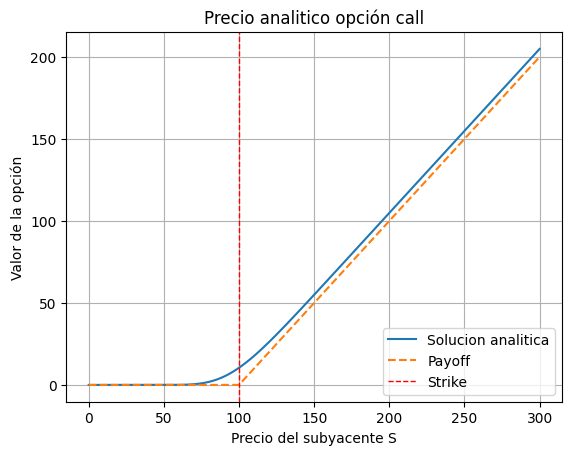

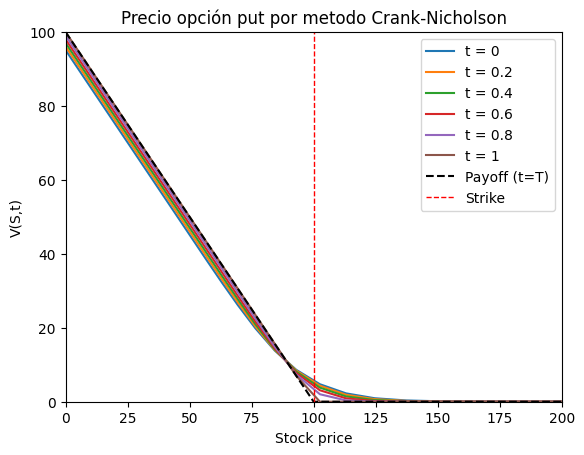

In [ ]:
# Gráficos de solución análitica
def analytic_graph( put_or_call="call", Smax=300, K=100, r=0.05, sigma=0.2, T=1, N=1000):
  S, V = analytic_sol(Smax, K, r, sigma, T, N, put_or_call) #hacemos que S sea 3 veces K para simular un Smax alto.
  S, payoff_vals = payoff(Smax, K, r, sigma, T, N, put_or_call) #hacemos que S sea 3 veces K para simular un Smax alto.
  plt.plot(S, V, label="Solucion analitica")
  plt.title(f"Precio analitico opción {put_or_call}")
  plt.plot(S, payoff_vals, label="Payoff", linestyle="--")
  plt.xlabel("Precio del subyacente S")
  plt.ylabel("Valor de la opción")
  plt.axvline(x=K, color='red', linestyle='--', linewidth=1, label='Strike')
  plt.legend()
  plt.grid(True)
  plt.show()

#Gráficos de solución por Método Explicito/Implicito/Crank-Nicholson
def method_graph(method="Crank-Nicholson", put_or_call="call", Smax=300, K=100, r=0.05, sigma=0.2, T=1, t_list=[0, 0.2, 0.4, 0.6, 0.8, 1], Nx=200, Nt=200, analytic_N=1000):
  if method == "explicit":
    for t in t_list:
      S, V = explicit_method(put_or_call, Smax, K, r, sigma, T, t, Nx, Nt)
      plt.plot(S, V, label=f't = {t}')
  elif method == "implicit":
    for t in t_list:
      S, V = implicit_method(put_or_call, Smax, K, r, sigma, T, t, Nx, Nt)
      plt.plot(S, V, label=f't = {t}')
  elif method == "Crank-Nicholson":
    for t in t_list:
      S, V = Crank_Nicholson_method(put_or_call, Smax, K, r, sigma, T, t, Nx, Nt)
      plt.plot(S, V, label=f't = {t}')
  else:
    raise ValueError("El método debe ser 'explicit', 'implicit' o 'Crank-Nicholson'.")

  S, payoff_vals = payoff(Smax, K, r, sigma, T, analytic_N, put_or_call)
  plt.plot(S, payoff_vals, color='black', label="Payoff (t=T)", linestyle="--")
  plt.title(f"Precio opción {put_or_call} por metodo {method}")
  plt.xlabel("Stock price")
  plt.ylabel("V(S,t)")
  plt.axvline(x=K, color='red', linestyle='--', linewidth=1, label='Strike')
  plt.xlim(0,2*K)
  plt.ylim(0,K)
  plt.legend()
  plt.show()

analytic_graph("call")
method_graph("Crank-Nicholson", "put")

# Punto 4 - Convergencia

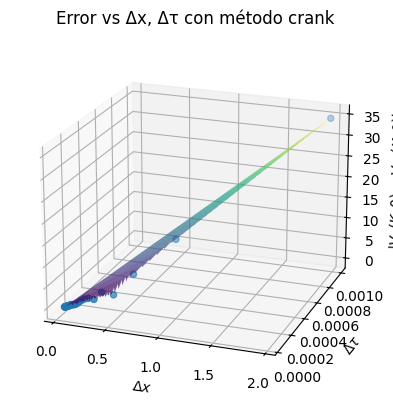

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from matplotlib import cm

def convergence_study(method="explicit", Nx_list=[50, 100, 200, 400], Nt_list=[50, 100, 200, 400], put_or_call="call", Smax=300, K=100, r=0.05, sigma=0.2, T=1, t=0):
    """
    Muestra cómo cambia el error |V_Δ(K,0) - V_BS(K,0)| al refinar Δx y Δτ
    para la opción ATM (S0 = K). 'scheme' puede ser 'explicit', 'implicit'
    o 'crank'.
    """

    # Precio "verdadero" de Black-Scholes en S0 = K (ATM)
    S_bs, V_bs = analytic_sol(Smax=Smax, K=K, r=r, sigma=sigma, T=T, N=5000, put_or_call=put_or_call)

    V_BS_ATM = np.interp(K, S_bs, V_bs)  # interpolamos en S=K

    errors = []
    dx_list = []
    dtau_list = []

    for Nx, Nt in zip(Nx_list, Nt_list):

        # Resolvemos con el esquema elegido
        if method == "explicit":
            S_num, V_num = explicit_method(put_or_call, Smax, K, r, sigma, T, t, Nx, Nt)
        elif method == "implicit":
            S_num, V_num = implicit_method(put_or_call, Smax, K, r, sigma, T, t, Nx, Nt)
        elif method == "crank":
            S_num, V_num = Crank_Nicholson_method(put_or_call, Smax, K, r, sigma, T, t, Nx, Nt)
        else:
            raise ValueError("scheme debe ser 'explicit', 'implicit' o 'crank'.")

        # Precio numérico en S=K (ATM)
        V_num_ATM = np.interp(K, S_num, V_num)

        # Error escalar en ATM
        error = abs(V_num_ATM - V_BS_ATM)
        errors.append(error)

        # Obtenemos Δx y Δτ para ese (Nx, Nt)
        x, tau, lambda_tau_x, hx, htau = var_change(Smax, K, r, sigma, T, t, Nx, Nt)
        dx_list.append(hx)
        dtau_list.append(htau)

    # Gráfico
    dx_list = np.array(dx_list)
    dtau_list = np.array(dtau_list)
    errors = np.array(errors)

    DX, DT = np.meshgrid(np.linspace(min(dx_list), max(dx_list), 300), np.linspace(min(dtau_list), max(dtau_list), 300))
    grid_errors = griddata((dx_list, dtau_list), errors, (DX, DT), method='linear')

    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(dx_list, dtau_list, errors)
    ax.plot_surface(DX, DT, grid_errors, cmap=cm.viridis, edgecolor='none', antialiased=True, alpha=0.95, linewidth=0, rstride=1, cstride=1)

    ax.set_xlabel(r'$\Delta x$')
    ax.set_ylabel(r'$\Delta \tau$')
    ax.set_zlabel(r'$|V_\Delta(K,0) - V_{BS}(K,0)|$')
    ax.set_title(f'Error vs Δx, Δτ con método {method}')
    ax.view_init(elev=20, azim=-70)

    plt.show()

    return np.array(dx_list), np.array(dtau_list), np.array(errors)

i=0
Nx_list = [10]
Nt_list = [20]   # por ejemplo, refinás tiempo un poco más
while i < 25:
  Nx_list.append(Nx_list[-1] + 15)
  Nt_list.append(Nt_list[-1] + 20)
  i+=1

dx, dtau, err = convergence_study(method="crank", Nx_list=Nx_list, Nt_list=Nt_list, put_or_call="call", K=100, Smax=300)

